In [44]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("Plots", exist_ok=True)

df = pd.read_csv("../Data/clean/airbnb_cleaned.csv")

print(df.head())
print(df.info())

                                             title        lat        lng  \
0  ETERNA.Suite W Jaccuzi, Pyramids View & Balcony  29.973873  31.146603   
1                                 king khufu suite  29.986300  31.143100   
2                             Akasia Pyramids View  29.978100  31.145400   
3          Mountain Cave | Pyramids View & Jacuzzi  29.979090  31.146920   
4                               Heaven of Pyramids  29.978787  31.144191   

   rating_overall  reviews_count  rating_accuracy  rating_cleanliness  \
0            4.95          133.0             4.96                4.92   
1            5.00           62.0             5.00                5.00   
2            4.91          176.0             4.91                4.91   
3            4.92           12.0             5.00                4.75   
4            4.71          125.0             4.74                4.61   

   rating_value  rating_location  price_breakdown_baseprice_price  ...  \
0          4.92             4.

In [45]:
df.describe()

,lat,lng,rating_overall,reviews_count,rating_accuracy,rating_cleanliness,rating_value,rating_location,price_breakdown_baseprice_price,nightly_price,...,checkin_month,checkin_day,checkin_weekday,checkout_year,checkout_month,checkout_day,checkout_weekday,bedrooms,bathrooms,description_length
count,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,...,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000
mean,30.025959,31.227029,4.892532,24.039711,4.880129,4.831845,4.815215,4.830794,4634.024886,281.912924,...,5.068592,3.428400,3.765343,2026.002407,5.079422,8.122744,2.424789,3.108303,2.794224,123.389892
std,0.044188,0.179129,0.224385,51.354517,0.245564,0.253912,0.274981,0.218906,14262.973631,269.306010,...,0.571502,5.593185,1.257863,0.049029,0.589832,4.879448,1.161143,1.876376,2.235479,155.271560
min,29.870350,30.819080,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,62.830000,1.000000,...,1.000000,1.000000,0.000000,2026.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,29.988986,31.140070,4.892532,0.000000,4.880129,4.831845,4.815215,4.830794,635.760000,43.500000,...,5.000000,1.000000,4.000000,2026.000000,5.000000,6.000000,2.000000,2.000000,1.000000,24.500000
50%,30.027500,31.220950,4.892532,1.000000,4.880129,4.831845,4.815215,4.830794,1773.190000,210.750000,...,5.000000,1.000000,4.000000,2026.000000,5.000000,6.000000,2.000000,3.000000,2.000000,70.000000
75%,30.060300,31.331955,4.980000,26.000000,4.970000,4.940000,4.920000,4.925000,3628.890000,502.225000,...,5.000000,2.000000,4.000000,2026.000000,5.000000,7.000000,2.000000,4.000000,4.000000,164.500000
max,30.194450,31.672700,5.000000,498.000000,5.000000,5.000000,5.000000,5.000000,284164.830000,971.780000,...,12.000000,31.000000,6.000000,2027.000000,12.000000,31.000000,6.000000,14.000000,19.000000,1549.000000


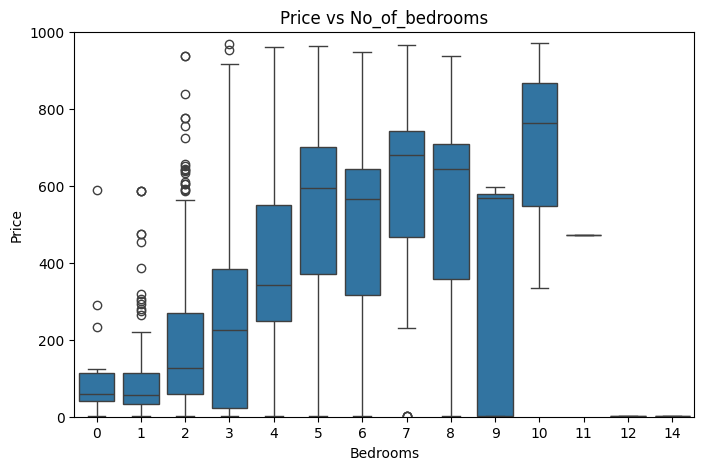

In [ ]:
# Price vs Bedrooms
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bedrooms'], y=df['nightly_price'])
plt.ylim(0, 1000)
plt.title("Price vs No_of_bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.savefig("Plots/price_vs_bedrooms.png")
plt.show()

In [47]:
df.columns

Index(['title', 'lat', 'lng', 'rating_overall', 'reviews_count',
       'rating_accuracy', 'rating_cleanliness', 'rating_value',
       'rating_location', 'price_breakdown_baseprice_price', 'nightly_price',
       'checkin_year', 'checkin_month', 'checkin_day', 'checkin_weekday',
       'checkout_year', 'checkout_month', 'checkout_day', 'checkout_weekday',
       'has_rating', 'bedrooms', 'bathrooms', 'description_length', 'has_wifi',
       'has_pool', 'view_type', 'listing_tier', 'proximity_to_landmarks',
       'target_guest'],
      dtype='object')

In [48]:
# Amenities Comparison
amenities = ['has_wifi','has_pool']
avg_prices = [df[df[a]==True]['price_breakdown_baseprice_price'].mean() for a in amenities]
avg_ratings = [df[df[a]==True]['rating_overall'].mean() for a in amenities]

C:\Users\Tarek\AppData\Local\Temp\ipykernel_6660\1620849828.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=amenities, y=avg_prices, palette="viridis")


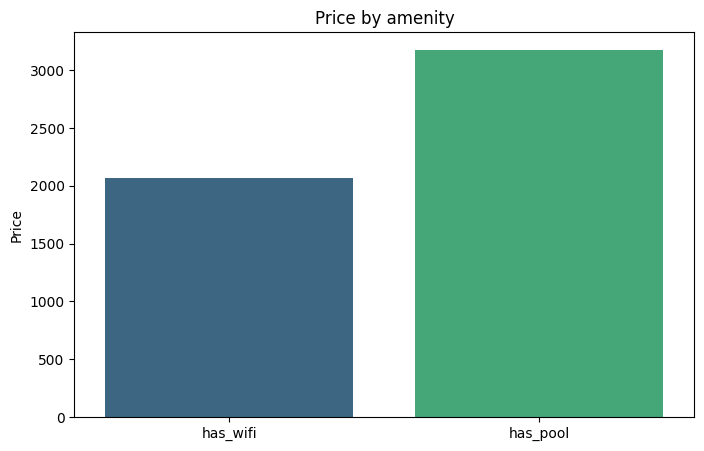

In [78]:
plt.figure(figsize=(8,5))
sns.barplot(x=amenities, y=avg_prices, palette="viridis")
plt.title("Price by amenity")
plt.ylabel("Price")
plt.savefig("Plots/price_by_amenity.png")
plt.show()

C:\Users\menna\AppData\Local\Temp\ipykernel_14808\2168450003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_reviews['title'], x=top_reviews['reviews_count'], palette="coolwarm")


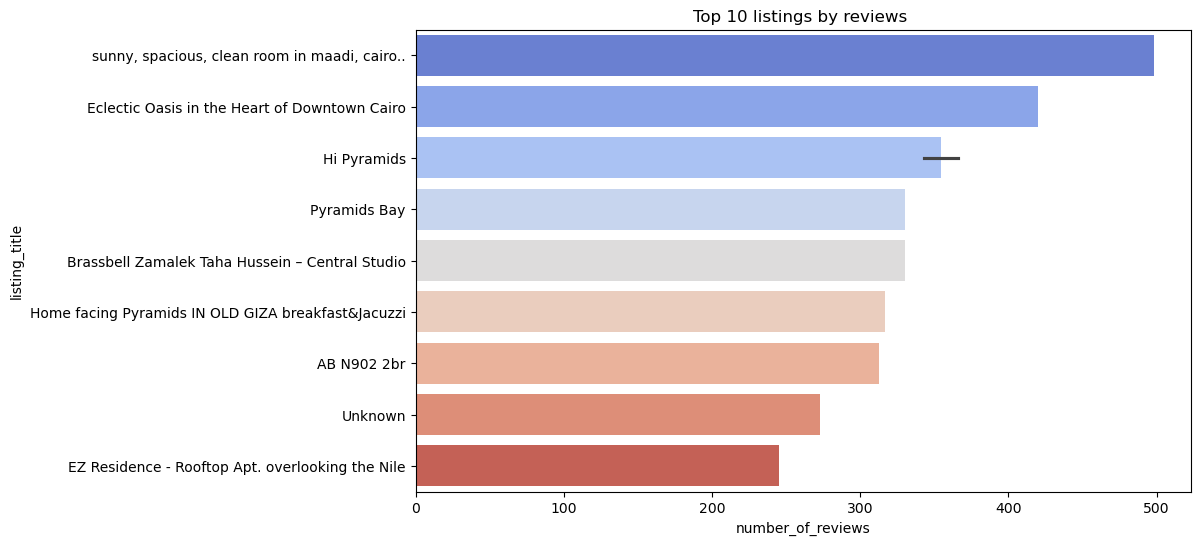

In [ ]:
# Top 10 listings by reviews
top_reviews = df.nlargest(10, 'reviews_count')[['title','reviews_count','rating_overall','price_breakdown_baseprice_price']]
plt.figure(figsize=(10,6))
sns.barplot(y=top_reviews['title'], x=top_reviews['reviews_count'], palette="coolwarm")
plt.title("Top 10 listings by reviews ")
plt.xlabel("number_of_reviews")
plt.ylabel("listing_title")
plt.savefig("Plots/top10_reviews.png")
plt.show()

In [65]:
# ── Helper ──────────────────────────────────────────────────────────────────
def parse_list_col(val):
    try:
        if isinstance(val, str) and val.startswith('['):
            return ast.literal_eval(val)
        return [val]
    except:
        return [val]

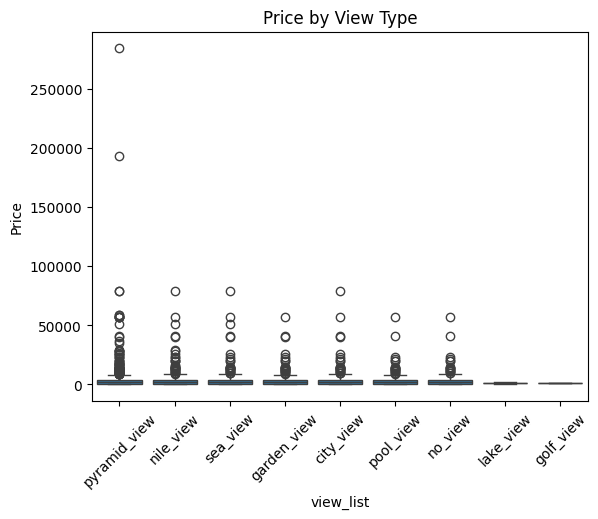

In [85]:
df['view_list'] = df['view_type'].apply(parse_list_col)

# Explode so each view gets its own row
df_exploded = df.explode('view_list').reset_index(drop=True)

# Now plot
sns.boxplot(x='view_list', y='price_breakdown_baseprice_price', data=df_exploded)
plt.xticks(rotation=45)
plt.title('Price by View Type')
plt.ylabel('Price')
plt.savefig('../Plots/price_by_view_type.png', bbox_inches='tight', dpi=150)
plt.show()

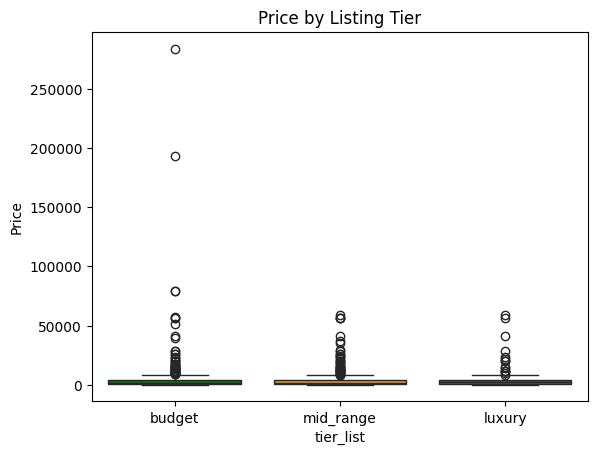

In [86]:
df['tier_list'] = df['listing_tier'].apply(parse_list_col)
df_tier_exploded = df.explode('tier_list').reset_index(drop=True)

# Plot
sns.boxplot(x='tier_list', y='price_breakdown_baseprice_price', data=df_tier_exploded,
            order=['budget', 'mid_range', 'luxury'],
            hue='tier_list',
            hue_order=['budget', 'mid_range', 'luxury'],
            palette=['green','orange','red'],
            legend=False)
plt.title('Price by Listing Tier')
plt.ylabel('Price')
plt.savefig('../Plots/price_by_listing_tier.png', bbox_inches='tight', dpi=150)
plt.show()

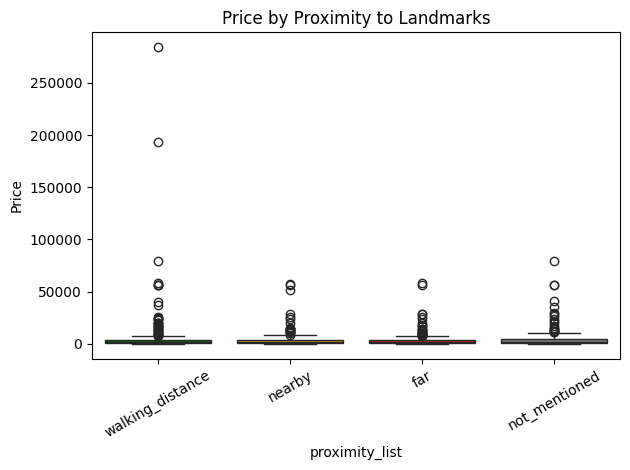

In [87]:
# ── Proximity to Landmarks ───────────────────────────────────────────────────
df['proximity_list'] = df['proximity_to_landmarks'].apply(parse_list_col)
df_proximity_exploded = df.explode('proximity_list').reset_index(drop=True)

sns.boxplot(x='proximity_list', y='price_breakdown_baseprice_price', data=df_proximity_exploded,
            order=['walking_distance', 'nearby', 'far', 'not_mentioned'],
            hue='proximity_list',
            hue_order=['walking_distance', 'nearby', 'far', 'not_mentioned'],
            palette=['green', 'orange', 'red', 'gray'],
            legend=False)
plt.title('Price by Proximity to Landmarks')
plt.xticks(rotation=30)
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('../Plots/price_by_proximity.png', bbox_inches='tight', dpi=150)
plt.show()

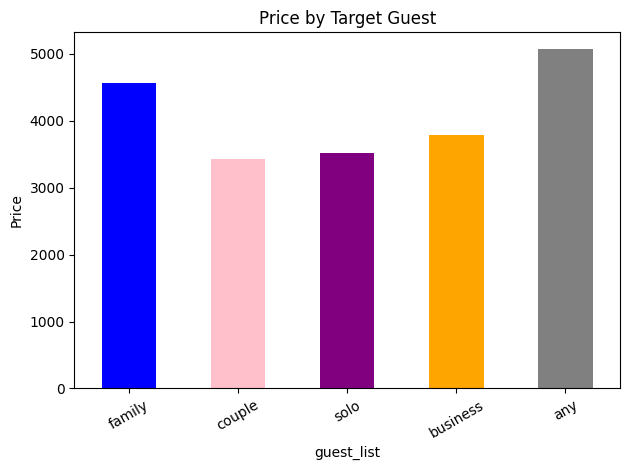

In [88]:
# ── Target Guest vs Rating ────────────────────────────────────────────────────
df['guest_list'] = df['target_guest'].apply(parse_list_col)
df_guest_exploded = df.explode('guest_list').reset_index(drop=True)

df_guest_exploded.groupby('guest_list')['price_breakdown_baseprice_price'].mean().reindex(
    ['family', 'couple', 'solo', 'business', 'any']
).plot(kind='bar', color=['blue', 'pink', 'purple', 'orange', 'gray'])
plt.title('Price by Target Guest')
plt.ylabel('Price')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../Plots/price_by_guest.png', bbox_inches='tight', dpi=150)
plt.show()

##
higher sentiment -> higher price?



In [ ]:
df.columns

Index(['title', 'lat', 'lng', 'rating_overall', 'reviews_count',
       'rating_accuracy', 'rating_cleanliness', 'rating_value',
       'rating_location', 'price_breakdown_baseprice_price', 'nightly_price',
       'checkin_year', 'checkin_month', 'checkin_day', 'checkin_weekday',
       'checkout_year', 'checkout_month', 'checkout_day', 'checkout_weekday',
       'has_rating', 'bedrooms', 'bathrooms', 'description_length', 'has_wifi',
       'has_pool', 'has_pyramid_view', 'view_type', 'listing_tier',
       'proximity_to_landmarks', 'target_guest'],
      dtype='object')

In [35]:
import pandas as pd
df_merged = pd.read_csv('../Data/clean/correlation_analysis.csv')
df_merged.head()

,room_id,avg_sentiment_score,price_breakdown_baseprice_price
0,981120709957763653,0.401794,225.00
1,1196851743231572540,0.370211,405.11
2,1199193622730754940,0.413260,432.66
3,1237474025614245965,0.374124,718.35
4,1258668362052840121,0.314164,257.58


C:\Users\Tarek\AppData\Local\Temp\ipykernel_6660\1259707571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_category', y='price_breakdown_baseprice_price', data=df_merged,


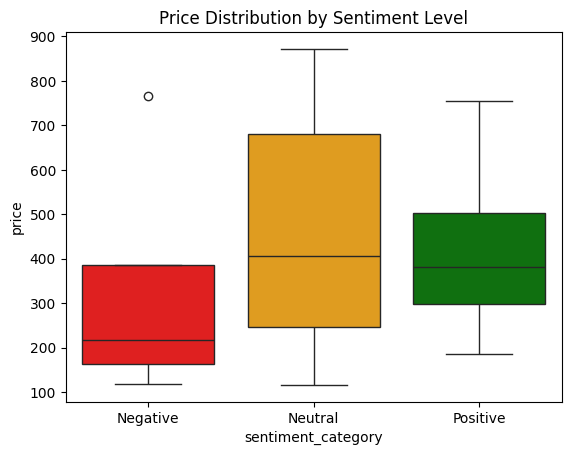

In [ ]:
# Recreate sentiment_category column
df_merged['sentiment_category'] = pd.cut(df_merged['avg_sentiment_score'],
                                          bins=3,
                                          labels=['Negative', 'Neutral', 'Positive'])

# Now plot
sns.boxplot(x='sentiment_category', y='price_breakdown_baseprice_price', data=df_merged,
            order=['Negative', 'Neutral', 'Positive'],
            palette=['red','orange','green'])
plt.title('Price Distribution by Sentiment Level')
plt.xlabel("sentiment_category")
plt.ylabel("price")
plt.savefig("../Plots/sentiment_price.png")
plt.show()